In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.cluster import KMeans 
import seaborn as sns

In [3]:
#Loading the dataset
df=pd.DataFrame(pd.read_csv('Mall_Customers - Mall_Customers.csv'))

In [4]:
# Shape of Dataset
df.shape

(200, 5)

In [5]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
#Datatypes in dataset
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [8]:
#Describing the data
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
#number of zeros
(df==0).sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
#Check for Null Values
(df.isnull()).sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
df=df.drop(columns=['CustomerID'])

In [13]:
df.replace({
    'Genre':{'Male':1,'Female':0}
},inplace=True)

C:\Users\ARJUN\AppData\Local\Temp\ipykernel_10856\1041624969.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [14]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [15]:
df.mean()

Genre                      0.44
Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

In [16]:
df.median()

Genre                      0.0
Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64

In [17]:
df.mode()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0.0,32.0,54,42.0
1,NaN,NaN,78,NaN


In [18]:
df.std()

Genre                      0.497633
Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64

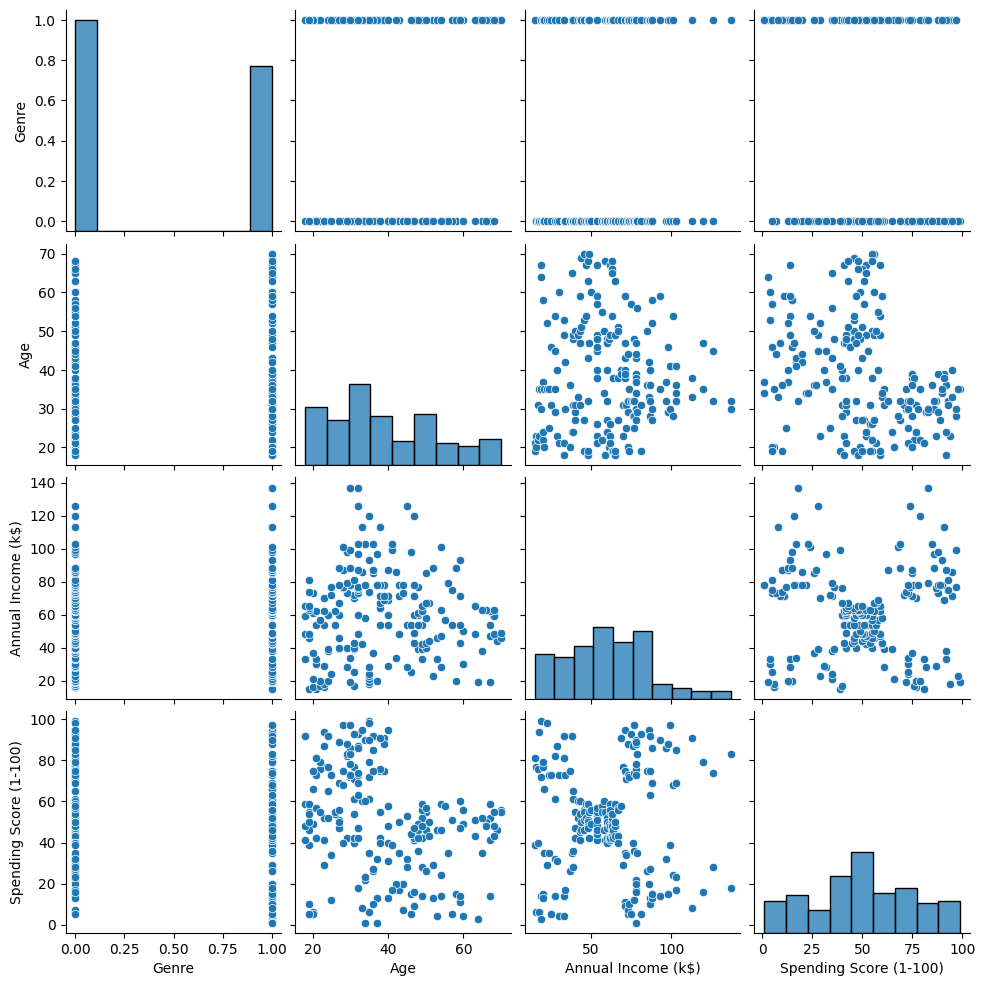

In [19]:
 sns.pairplot(df)

<Axes: ylabel='Count'>

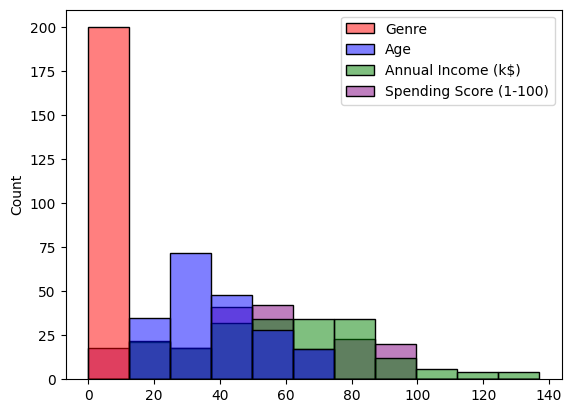

In [21]:
sns.histplot(df,palette=['red','blue','green','purple'])

<Axes: xlabel='Spending Score (1-100)', ylabel='count'>

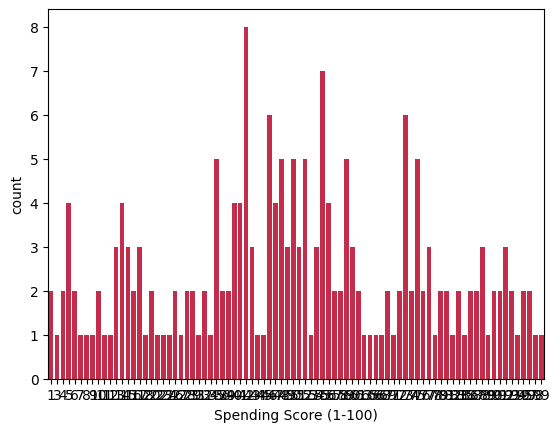

In [27]:
sns.countplot(data=df,x=df['Spending Score (1-100)'],color='crimson')

<Axes: >

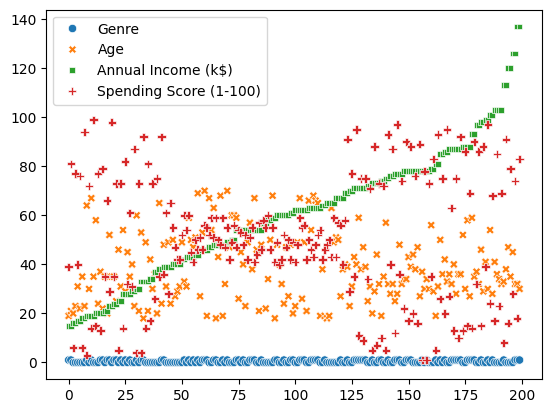

In [28]:
sns.scatterplot(df)

In [32]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [33]:
kmeans=KMeans(n_clusters=3,random_state=0)

In [34]:
df['Cluster']=kmeans.fit_predict(X)

In [37]:
print(df[['Cluster']])

     Cluster
0          0
1          0
2          0
3          0
4          0
..       ...
195        1
196        2
197        1
198        2
199        1

[200 rows x 1 columns]


In [38]:
centers = kmeans.cluster_centers_

In [39]:
centers

array([[44.15447154, 49.82926829],
       [86.53846154, 82.12820513],
       [87.        , 18.63157895]])

In [42]:
wcss = []
for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [43]:
wcss

[269981.28,
 185917.14253928524,
 106348.37306211119,
 73679.78903948836,
 44448.45544793371,
 38858.9599751439,
 31969.426550235476,
 29858.483597603947,
 22209.851608025543,
 20786.936692059156,
 18612.22286800968,
 17083.672501709312,
 16511.94737056389,
 15599.148331445112,
 14697.298899626932]